In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# load the data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# drop IDs and split X, y
X = train_df.drop(['seqn', 'MetabolicSyndrome'], axis=1)
y = train_df['MetabolicSyndrome']
X_test_final = test_df.drop(['id', 'seqn'], axis=1)

In [18]:
# define which cols are which
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# pipeline for numbers (impute then scale)
num_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline for categories
cat_proc = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# combine everything
preprocessor = ColumnTransformer(transformers=[
    ('num', num_proc, num_cols),
    ('cat', cat_proc, cat_cols)
])

# run it and split 80/20
X_proc = preprocessor.fit_transform(X)
X_test_proc = preprocessor.transform(X_test_final)
X_train, X_val, y_train, y_val = train_test_split(X_proc, y, test_size=0.2, random_state=42)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_19216\1072718267.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns


In [19]:
k_list = [3, 5, 7]
metrics = ['euclidean', 'manhattan']
best_knn_acc = 0
best_knn_params = None

for k in k_list:
    for m in metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=m)
        knn.fit(X_train, y_train)
        pred = knn.predict(X_val)
        acc = accuracy_score(y_val, pred)
        print(f"Testing k={k}, metric={m} -> Acc: {acc}")
        
        if acc > best_knn_acc:
            best_knn_acc = acc
            best_knn_params = (k, m)

print("Best kNN:", best_knn_params)

Testing k=3, metric=euclidean -> Acc: 0.8125
Testing k=3, metric=manhattan -> Acc: 0.8046875
Testing k=5, metric=euclidean -> Acc: 0.8098958333333334
Testing k=5, metric=manhattan -> Acc: 0.7890625
Testing k=7, metric=euclidean -> Acc: 0.828125
Testing k=7, metric=manhattan -> Acc: 0.8203125
Best kNN: (7, 'euclidean')


In [20]:
smooth_vals = [1e-9, 1e-8, 1e-7]
best_nb_acc = 0
best_nb_param = None

for v in smooth_vals:
    nb = GaussianNB(var_smoothing=v)
    nb.fit(X_train, y_train)
    pred = nb.predict(X_val)
    acc = accuracy_score(y_val, pred)
    print(f"Testing smoothing={v} -> Acc: {acc}")
    
    if acc > best_nb_acc:
        best_nb_acc = acc
        best_nb_param = v

print("Best NB smoothing:", best_nb_param)

Testing smoothing=1e-09 -> Acc: 0.7864583333333334
Testing smoothing=1e-08 -> Acc: 0.7864583333333334
Testing smoothing=1e-07 -> Acc: 0.7864583333333334
Best NB smoothing: 1e-09


In [21]:
# build final models using the best params found
final_knn = KNeighborsClassifier(n_neighbors=best_knn_params[0], metric=best_knn_params[1])
final_nb = GaussianNB(var_smoothing=best_nb_param)

final_knn.fit(X_train, y_train)
final_nb.fit(X_train, y_train)

print("Ready for evaluation and ROC curves.")

Ready for evaluation and ROC curves.


Generating Confusion Matrix...


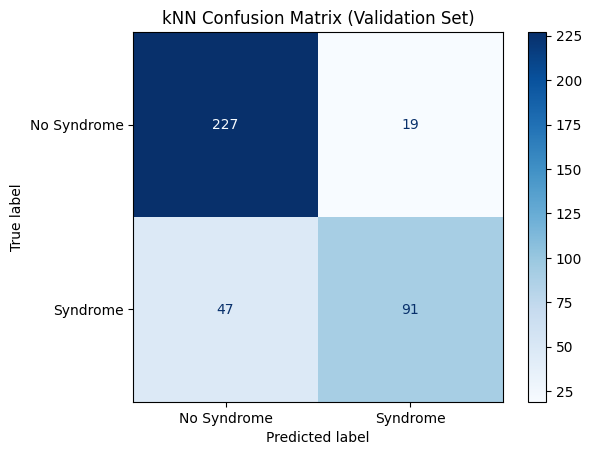


--- kNN Performance Metrics ---
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       246
           1       0.83      0.66      0.73       138

    accuracy                           0.83       384
   macro avg       0.83      0.79      0.80       384
weighted avg       0.83      0.83      0.82       384


--- Naive Bayes Performance Metrics ---
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       246
           1       0.74      0.62      0.68       138

    accuracy                           0.79       384
   macro avg       0.77      0.75      0.76       384
weighted avg       0.78      0.79      0.78       384


Generating ROC Curve...


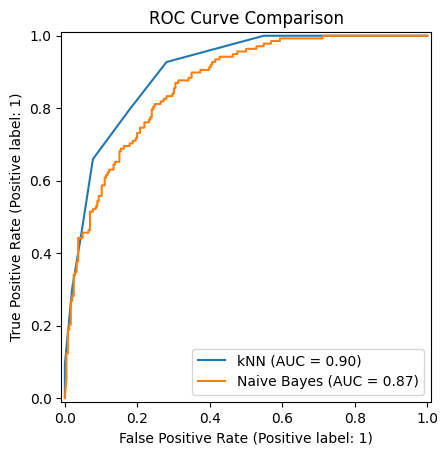

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

# 1. Confusion Matrix - Visualizing True/False Positives and Negatives
print("Generating Confusion Matrix...")
cm = confusion_matrix(y_val, final_knn.predict(X_val))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Syndrome', 'Syndrome'])
disp.plot(cmap='Blues')
plt.title('kNN Confusion Matrix (Validation Set)')
plt.show()

# 2. Classification Metrics - Accuracy, Recall, Precision, and F1-score
print("\n--- kNN Performance Metrics ---")
print(classification_report(y_val, final_knn.predict(X_val)))

print("\n--- Naive Bayes Performance Metrics ---")
print(classification_report(y_val, final_nb.predict(X_val)))

# 3. ROC-AUC Graph - Comparing both models
print("\nGenerating ROC Curve...")
ax = plt.gca()
RocCurveDisplay.from_estimator(final_knn, X_val, y_val, ax=ax, name='kNN')
RocCurveDisplay.from_estimator(final_nb, X_val, y_val, ax=ax, name='Naive Bayes')
plt.title('ROC Curve Comparison')
plt.show()

In [29]:
# 1. Use 'predict_proba' instead of 'predict' to get the ROC-AUC score higher
# We take the second column [:, 1] which is the probability of having the syndrome
final_probs = final_knn.predict_proba(X_test_proc)[:, 1]

# 2. Create the official dataframe
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'MetabolicSyndrome': final_probs
})

# 3. Save it to the file name you'll upload
submission_df.to_csv('Project2_Submission_Final.csv', index=False)

print("Final probability-based submission created!")

Final probability-based submission created!
